In [39]:

from __future__ import annotations

import random

import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.special import comb
from scipy import linalg

from sage.combinat.combinatorial_map import combinatorial_map

from sage.combinat.tamari_lattices import TamariLattice

from sage.structure.global_options import GlobalOptions
from sage.structure.parent import Parent
from sage.structure.unique_representation import UniqueRepresentation
from sage.categories.finite_enumerated_sets import FiniteEnumeratedSets
from sage.categories.infinite_enumerated_sets import InfiniteEnumeratedSets
from sage.categories.posets import Posets

from sage.rings.integer import Integer
from sage.rings.rational_field import QQ
from sage.combinat.permutation import Permutation, Permutations
from sage.combinat.words.word import Word
from sage.combinat.set_partition import SetPartitions
from sage.misc.latex import latex
from sage.misc.lazy_import import lazy_import
from typing import TYPE_CHECKING

from collections import Counter

import time

np.set_printoptions(legacy='1.25')

# Merge sort with an argument for a compare function, deciding which ordering will be output.
def merge_sort(arr, start, end, compare):
    sorted_arr = [None] * (end - start + 1) 
    
    if start == end:
        sorted_arr[0] = arr[start]
        return sorted_arr

    left_start = start
    left_end = (start + end) // 2

    right_start = left_end + 1
    right_end = end

    left_sorted = merge_sort(arr, left_start, left_end, compare)
    right_sorted = merge_sort(arr, right_start, right_end, compare)

    i = 0  # current position in left part
    j = 0  # current position in right part

    k = 0

    while i < len(left_sorted) and j < len(right_sorted):
        a = left_sorted[i]
        b = right_sorted[j]
        decision = compare(a, b)
        if decision < 0:
            sorted_arr[k] = a
            i += 1
        else:
            sorted_arr[k] = b
            j += 1
        k += 1

    while i < len(left_sorted):
        sorted_arr[k] = left_sorted[i]
        i += 1
        k += 1

    while j < len(right_sorted):
        sorted_arr[k] = right_sorted[j]
        j += 1
        k += 1

    return sorted_arr

# Compares two Dyck words x and y based on the dominance ordering, wherein x>y if it is higher than y at every point and vice versa. Ties are broken by highest peak and then by location of highest peaks.
def dominance_compare(x, y):
    poset = DyckWords().height_poset()
    if poset.le(x,y) and not poset.le(y,x):
        return -1
    if poset.le(y,x) and not poset.le(x,y):
        return 1
    else: 
        xh = x.height()
        yh = y.height()
        if xh > yh: 
            return 1
        if xh < yh:
            return -1
        xp = x.peaks()
        yp = y.peaks()
        return (xp > yp) - (xp < yp)

# Recursive generation of the dyck words. Results in a default lexicographic ordering. This ordering turns out to be a refinement of the Tamari ordering, and so seems to be the natural choice. 
def dyck_words(n, sorting = "lex"):
    out=[]
    D = DyckWords(n)
    def rec(w,o,c):
        if o==n and c==n:
            if sorting == "tam":
                out.append(D(w))
            else:
                out.append(DyckWord(w)); 
            return
        if o<n: rec(w+'(', o+1, c)
        if c<o: rec(w+')', o, c+1)
    rec('',0,0) 
    return out

# Class representing a meander built from two dyck words. The arches are reprented by a list of tuples derived from Sagemath's tunnels function. The order is calculated via
# permutation representation (see section 1.1.2).
class Meander:
    def __init__(self, x, y):
        self.topDyck = x;
        self.botDyck = y;
        self.size = len(x)
        top_arches = [tuple(a0 + 1 if i == 0 else a0 for i, a0 in enumerate(a))
                       for a in x.tunnels()]
        bot_arches = [tuple(b0 + 1 if i == 0 else b0 for i, b0 in enumerate(b))
                       for b in y.tunnels()]

        self.topPerm = Permutation(top_arches)
        self.botPerm = Permutation(bot_arches)
        
        self.perm = self.botPerm.left_action_product(self.topPerm)
        self.order = len(self.perm.cycle_type())/2
        
    def getPerm(self):
        return self.perm.cycle_tuples();

    def getTop(self):
        return self.topDyck;

    def getBot(self):
        return self.botDyck;

    def getOrder(self):
        return self.order;

    def getCycleType(self):
        return self.perm.cycle_type();
    
# Function creating the meander matrix, AKA gram matrix of TL_n. Uses a sorted list of Dyck words and takes the type of sorting as input for funky cases. Entry i,j is the number of connected
# components, or the trace, of the meandric system formed by Dyck words i and j
def meander_matrix(n, sorting = "lex"):
    R = PolynomialRing(QQ, 't')
    t = R.gen()
    q = (t)
    T = TamariLattice(n)
    D = DyckWords(n)

    dws = dyck_words(n, sorting)

    if sorting == "dom": 
        arches = merge_sort(dws, 0, len(dws)-1, dominance_compare)
        assert set(arches) == set(dws)
    elif sorting == "tam":
        arches = D(T)
    else:
        arches = dws

    l = len(arches)
    mM = np.array([[0]*l for _ in range(l)])

    heights = []

    for i in range(l):
        heights.append(D(arches[i]).height())
        for j in range(i, l): 
            if sorting == "tam":
                value = Meander(D(arches[i]), D(arches[j])).getOrder()
            else:
                value = Meander(arches[i], arches[j]).getOrder()
            mM[i][j] = value
            mM[j][i] = value

    return mM, arches, heights

# Function that records the number and size of the connected components in a meandric system as a symmetric powersum function, where p_i^n represents n 2i sized components. 
def stanley_poly(m):
    # R = PolynomialRing(QQ, m.size, "p")
    p = SymmetricFunctions(QQ).p()
    # p = R.gens()
    entry = 1
    counts = Counter(m.getCycleType())
    for k in counts:
        entry *= p[k]**(Integer(counts[k]/2))
    return entry

# Creates an analog to the meander_matrix function where the entries are Stanley polynomials generated by stanley_poly(m)
def stanley_matrix(n):
    dws = dyck_words(n, "norm")
    arches = merge_sort(dws, 0, len(dws)-1, dominance_compare)
    D = DyckWords(n)
    l = len(arches)
    hM = [[0]*l for _ in range(l)]
    Sym = SymmetricFunctions(QQ)
    mon = Sym.m()
    
    for i in range(l):
        for j in range(i, l): 
            m = Meander(D(arches[i]), D(arches[j]))
            value = stanley_poly(m)
            hM[i][j] = value
            hM[j][i] = value
    return hM

# Function converting between Chebyshev polynomials of the second kind, with its standard normalization, to Di Francesco's nonstandard normalization. We refer to these as Di Francesco polynomials. 
def DF_chebyshev(gen, k):
    return chebyshev_U(k, gen/2)

# Funtion returning constant c_{n,h} defined in Di Francesco's paper. 
def c_nh(n, h):
    return comb(n,(n-h)/2, exact=true) - comb(n, (n-h)/2 - 1, exact=true)

# Function implementing Di Francesco's formula for the determinant of the meandric matrix. 
def meander_determinant(M, n):
    R = PolynomialRing(QQ, 't')
    t = R.gen();
    mu = (t)
    ret = DF_chebyshev(mu, 0)
    for i in range(n):
        m = i+1
        ret *= DF_chebyshev(mu, m)^(c_nh(2*n,2*m)-c_nh(2*n,2*m+2))
    return ret

def bareiss_det(M):
    n = len(M[0])
    A = [row[:] for row in M]

    for k in range(n - 1):
        pivot = A[k][k]
        denom = 1 if k == 0 else A[k - 1][k - 1]

        for i in range(k + 1, n):
            for j in range(k + 1, n):
                A[i][j] = (A[i][j] * pivot - A[i][k] * A[k][j]) / denom
            A[i][k] = 0

    return numerator(A[-1][-1])

# Function checking the schur positivity of a symmetric function factorization
def schur_positive(factorization):
    print(factorization)
    
    unit_not_used = true
    for fac, exp in factorization:
        if not (fac^exp).is_schur_positive():
            if unit_not_used:
                if not (factorization.unit()*(fac^exp)).is_schur_positive():
                    print(fac, exp, (fac^exp).is_schur_positive())
                    return False
                continue
            print(fac, exp, (fac^exp).is_schur_positive())
            return False
    return True

# Calculates the trace of a matrix squared
def trace_M_squared(M):
    n = len(M)
    MM = [[sum(M[i][k] * M[k][j] for k in range(n)) for j in range(n)] for i in range(n)]
    return sum(MM[i][i] for i in range(n))

# Rotates a Dyck word according to the symmtric action of r on its permutation
def rotate_dyck(x):
    n = len(x)

    D = DyckWords(n)
    
    new_tunnels = []
    for a,b in D(x).tunnels():
        a_new = (a + 1) % n
        b_new = (b) % n
        new_tunnels.append((a_new, b_new))
    word = [''] * n
    for a,b in new_tunnels:
        if a < b:
            word[a] = '('
            word[b] = ')'
        else:
            word[b] = '('
            word[a] = ')'
    
    s = ''.join(word)
    
    return DyckWord(s)

# Returns a list of tuples of indeces as the orbit of the meandric system (i,j) under the symmetric action r.
def orbit_indices(arches, index_dict, i, j = None, action = "dihedral):
    n = len(arches)
    orbit = set()
    D = DyckWords()

    # Dyck word orbit
    if j == None:
        arch = arches[i]
        n = len(arch)

        while i not in orbit:
            orbit.add(i)
            arch = rotate_dyck(arch)
            i = index_dict[tuple(D(arch))]

    # Meander orbit
    else:
        top = arches[i]
        bot = arches[j]
        n = len(top)
    
        while (i, j) not in orbit:
            orbit.add((i, j))
            if action = "dihedral":
                orbit.add((j,i))
            
            top = rotate_dyck(top)
            bot = rotate_dyck(bot)
            
            i = index_dict[tuple(D(top))]
            j = index_dict[tuple(D(bot))]
        
    return orbit

# Takes as input all the arch diagrams of a certain size and returns a list of the orbits
def arch_orbits(arches):
    l = len(arches)
    index_dict = {}
    for k in range(l):
        x = list(arches[k])
        index_dict[tuple(x)] = k

    visited = set()
    orbits = []

    for i in range(l):
        if i not in visited:
            orbit = orbit_indices(arches, index_dict, i)
            visited.update(orbit)
            orbits.append(orbit)

    return orbits

# Takes as input a meander matrix and a list of arches and returns a list of all the orbits.
def meander_orbits(mM, arches):
    l = len(arches)
    index_dict = {}
    for k in range(l):
        x = list(arches[k])
        # uncomment following line if using Tamari ordering
        # del x[-1]
        index_dict[tuple(x)] = k
    
    visited = set()
    orbits = []
    
    for i in range(l):
        for j in range(l):
            if mM[i,j] == 1 and (i,j) not in visited:
                # if (i,j) not in visited:
                orbit = orbit_indices(arches, index_dict, i, j)
                visited.update(orbit)
                orbits.append(orbit)
    
    return orbits

# Wrapper function, calls meander_orbits to calculate the orbits and then assigns the same color to every element of an orbit
def orbit_label_matrix(mM, arches):
    l = len(arches)
    labels = -np.ones((l,l))
    
    orbits = meander_orbits(mM, arches)
    # print(orbits)
    color_id = 0
    for color, orbit in enumerate(orbits):
        for (i,j) in orbit:
            labels[i][j] = color_id
        color_id += 1

    return labels, color_id, orbits

# returns a list of representatives of a set of orbits. For meanders, it just returns any item as the representative.
# For arch diagrams, it returns the index of the arch diagram of maximal height in the orbit. 
def get_reps(arches, orbits):
    reps = []
    if type(next(iter(orbits[0]))) == 'tuple':
        for o in orbits:
            reps.append(o[0])
    else:
        for o in orbits:
            max_item = -1
            for i in o:
                if arches[i].height() > arches[max_item].height():
                    max_item = i
            reps.append(max_item)
    return reps

# Calculates the component_sum_polynomial of a given arch diagram, as defined in the paper
def component_sum_polynomial(n, x):
    dws = dyck_words(n, "lex")
    R = PolynomialRing(QQ, 'q')
    q = R.gen()
    ret = 0
    coeffs = [0] * (n+1)
    for d in dws:
        m = Meander(x, d)
        ret += q^(m.getOrder())
        coeffs[m.getOrder()] += 1
    return np.polynomial.Polynomial(coeffs)

# Wrapper function that computes the component_sum_polynomial of representative arch diagrams
def arch_orbit_polynomials(n):
    arches = dyck_words(n, "lex")
    orbits = arch_orbits(arches)
    reps = get_reps(arches, orbits)
    polys = []
    for r in reps:
        polys.append(component_sum_polynomial(n, arches[r]))
    return polys, reps

# Wrapper function that produces graphs of the arch orbit polynomials of a certain size, with input for linspace variables. 
    def arch_polynomial_graphs(n, x1, x2):
    arches = dyck_words(n, "lex")
    polys, reps = arch_orbit_polynomials(n)
    for p in polys:
        print(p)
    for r in reps:
        draw_arch_diagram(arches[r])
        
    plt.cla()
    plt.figure(figsize=(5,5))
    
    x = np.linspace(x1, x2, 400)
    
    for i, p in enumerate(polys):
        if i == 0:
            color = "blue"      # min
            label = "min"
        elif i == len(polys) - 1:
            color = "red"       # max
            label = "max"
        else:
            color = "gray"      # middle ones
            label = None        # don't repeat legend entries
    
        plt.plot(x, p(x), color=color, label=label)
    
    plt.legend()
    plt.show()
    

Analysis and Visualizations: 

In [44]:

# Prints the entries of a matrix nicely (best if integers)
def matrix_print(M):
    s = [[str(e) for e in row] for row in M]
    lens = [max(map(len, col)) for col in zip(*s)]
    fmt = '\t'.join('{{:{}}}'.format(x) for x in lens)
    table = [fmt.format(*row) for row in s]
    print('\n'.join(table))

# Calculates various data of a matrix
def matrix_data(M, heights, should_print = true):
    import numpy as np
    import matplotlib.pyplot as plt

    print("========== MATRIX DATA ANALYSIS ==========\n")

    n = M.shape[0]
    print(f"Analyzing a {n} x {n} meander matrix.\n")

    heights = np.array(heights)
    num_components = M.sum(axis=1)
    unique_vals, first_indices = np.unique(num_components, return_index=True)
    
    # indices = first_indices[np.argsort(unique_vals)]
    indices = np.argsort(num_components)
    minima = np.where(num_components == num_components.min())[0]
    maxima = np.where(num_components == num_components.max())[0]
    values, counts = np.unique(M, return_counts=True)

    data = np.column_stack([heights, num_components])
    corr = np.corrcoef(data, rowvar=False)

    orbits = arch_orbits(arches)
    reps = get_reps(arches, orbits)
    rep_num_components = [num_components[r] for r in reps]
    rep_heights = [heights[r] for r in reps]
    rep_data = np.column_stack([heights, num_components])
    rep_corr = np.corrcoef(data, rowvar=False)

    if should_print:
        print("Correlation (heights vs. num_components):")
        print(corr, "\n")
    
        print("Heights:")
        print(heights, "\n")
    
        print("Row sums (num_components):")
        print(num_components, "\n")

    x = np.arange(len(num_components))

    # Plot 1: Row sums with best-fit line 
    coeffs = np.polyfit(x, num_components, 1)
    m, b = coeffs
    best_fit = m * x + b

    if should_print:
        plt.figure(figsize=(6,4))
        plt.scatter(x, num_components)
        plt.plot(x, best_fit)
        plt.xlabel("Row index")
        plt.ylabel("Number of components (row sum)")
        plt.title("Row sums with Best-Fit Line")
        plt.grid(True)
    
        print(f"Best-fit line: y = {m:.4f}x + {b:.4f}\n")
    
        # ---------- Plot 2: Distribution of row sums ----------
        plt.figure(figsize=(3,2))
        bins = int(np.sqrt(len(num_components)))
        plt.hist(num_components, bins=bins, alpha=0.6)
        plt.scatter(num_components, np.zeros_like(num_components))
        plt.xlabel("Number of components (row sum)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Row Sums")
    
        #  ---------- Plot 3: Distribution of Matrix Entries ----------
        plt.figure(figsize=(3,2))
        plt.bar(values, counts)
        
        plt.xlabel("Matrix entry value")
        plt.ylabel("Frequency")
        plt.title("Distribution of Matrix Entries")
        
        plt.show()
    
        # ---------- Plot 4: Matrix heatmap ----------
        plt.figure(figsize=(5,5))
        plt.matshow(M)
        plt.colorbar()
        plt.title("Meander Matrix Heatmap")
        plt.savefig("heatmap1.png", dpi=300, bbox_inches="tight")
        
        plt.show()

    return corr, rep_corr, num_components, minima, maxima, indices

# Draws an arch diagram
def draw_arch_diagram(dw, ax=None, n=None, flip=False):
    D = DyckWords(n)
    
    cycles = [tuple(a0 + 1 if i == 0 else a0 for i, a0 in enumerate(a)) for a in D(dw).tunnels()]
    
    if ax is None:
        fig, ax = plt.subplots(layout="constrained", figsize=(8, 3))
    
    if n is None:
        n = max(max(a) for a in cycles)

    xs = np.arange(1, n+1)

    """
    ax.scatter(xs, np.zeros_like(xs),
               color="black", zorder=3)
    """
   
    for (i, j) in cycles:
        r = (j - i) / 2
        cx = (i + j) / 2

        theta = np.linspace(0, np.pi, 200)
        x = cx + r * np.cos(theta)
        y = r * np.sin(theta)
        if flip:
            y*=-1

        ax.plot(x, y, "k", linewidth=1.5)

    return ax

# Draws a meander
def draw_meander(m, n=None):
    top_arches = m.getTop()
    bot_arches = m.getBot()
    
    if n is None:
        n = m.getOrder()

    fig, ax = plt.subplots(layout="constrained", figsize=(8, 5))

    # draw top above, bottom below
    draw_arch_diagram(top_arches, ax=ax, n=n)
    draw_arch_diagram(bot_arches, ax=ax, n=n, flip=True)

    # ax.set_aspect("equal", adjustable="box")
    # ax.set_xlim(0.5, n + 0.5)
    # ax.set_ylim(-n/2, n/2)
    # ax.axis("off")

    plt.show()
    return ax

Testing:

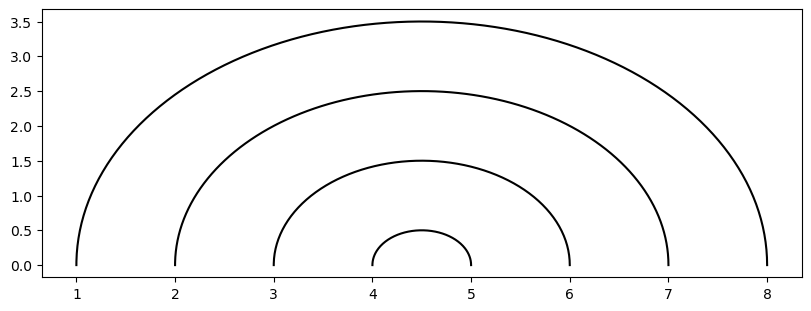

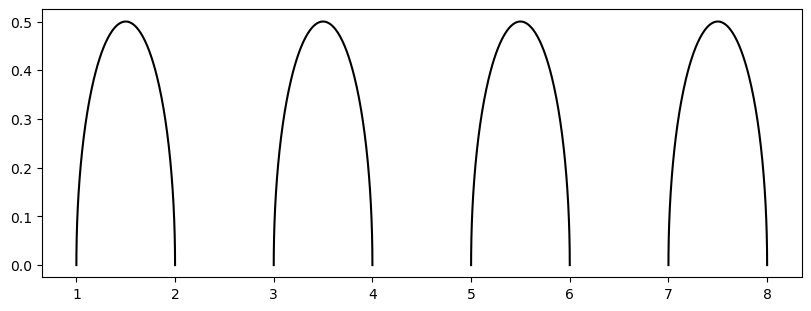

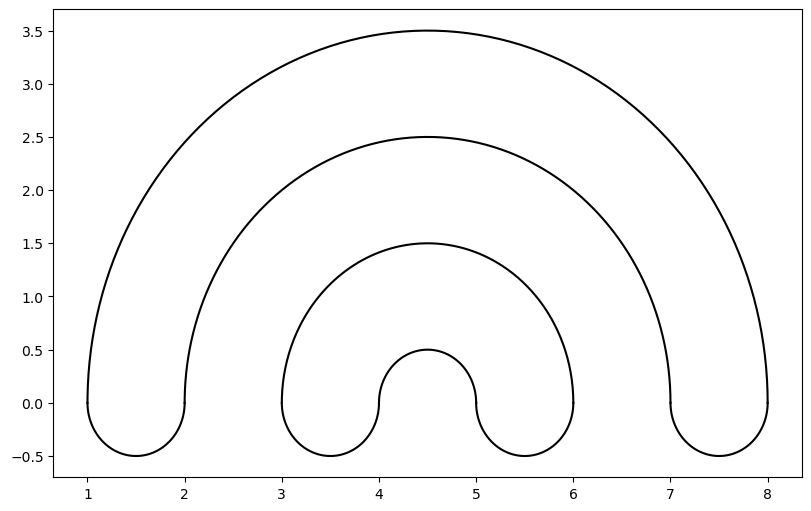

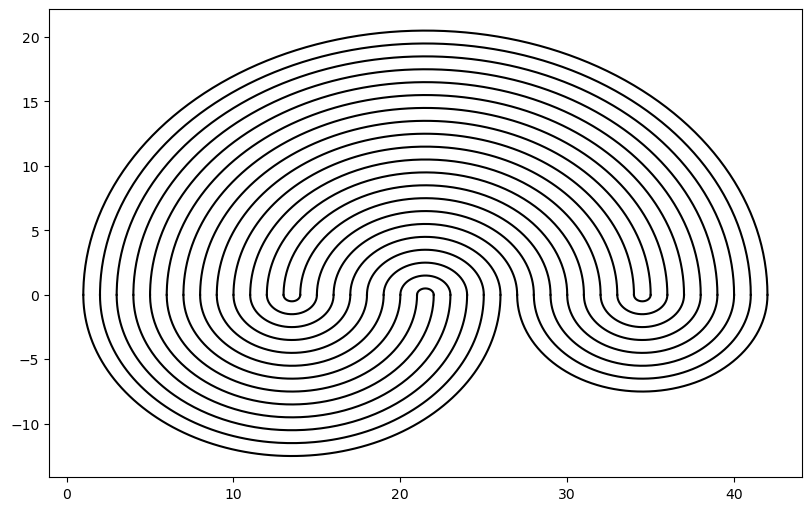

========== MATRIX DATA ANALYSIS ==========

Analyzing a 132 x 132 meander matrix.

Correlation (heights vs. num_components):
[[ 1.         -0.58965538]
 [-0.58965538  1.        ]] 

Heights:
[6 5 5 5 5 5 5 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 3 3 3 3 3 3 3 3 4 3 3
 3 3 3 3 3 3 3 3 3 3 3 5 4 4 4 4 4 3 3 3 3 3 3 3 3 4 3 3 3 3 2 2 2 2 3 2 2
 2 2 4 3 3 3 3 2 2 2 2 3 2 2 2 2 5 4 4 4 4 4 3 3 3 3 3 3 3 3 4 3 3 3 3 2 2
 2 2 3 2 2 2 2 4 3 3 3 3 2 2 2 2 3 2 2 2 1] 

Row sums (num_components):
[330 350 350 350 350 330 350 386 368 380 350 350 376 368 350 350 386 350
 330 350 350 368 374 368 350 376 414 394 386 368 394 368 350 380 350 368
 376 350 374 414 376 350 368 330 350 350 350 386 350 380 368 386 350 368
 394 394 368 376 414 374 350 368 386 394 414 376 414 462 414 386 394 350
 380 368 368 394 330 350 350 350 350 386 368 350 376 350 368 374 376 414
 330 350 350 350 350 350 386 368 380 350 376 368 350 386 350 368 374 368
 376 414 394 368 394 350 368 376 374 414 350 380 368 386 368 394 394 376


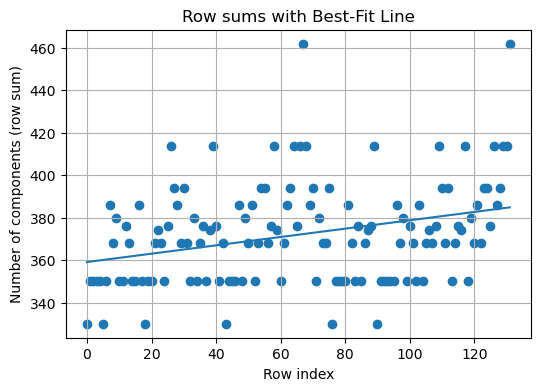

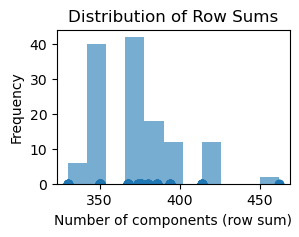

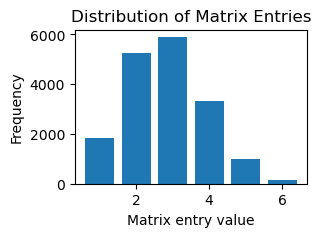

<Figure size 500x500 with 0 Axes>

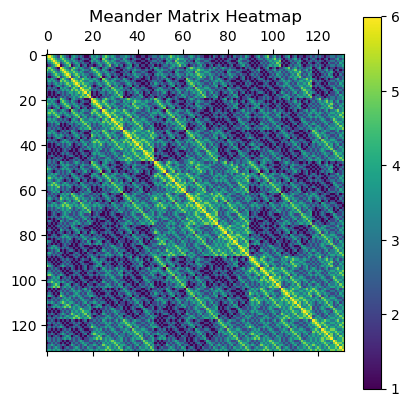

Number of orbits:  81
Size 2: 1 sets
Size 6: 1 sets
Size 8: 1 sets
Size 12: 5 sets
Size 24: 73 sets


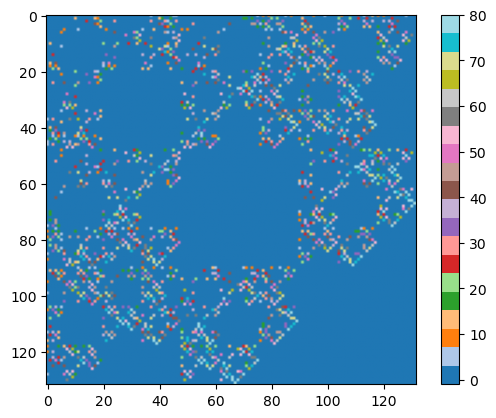

Orbit Analysis of n =  1 .
Number of orbits:  1
Size 1: 1 sets
Orbit Analysis of n =  2 .
Number of orbits:  1
Size 2: 1 sets
Orbit Analysis of n =  3 .
Number of orbits:  2
Size 2: 1 sets
Size 6: 1 sets
Orbit Analysis of n =  4 .
Number of orbits:  4
Size 2: 1 sets
Size 8: 1 sets
Size 16: 2 sets
Orbit Analysis of n =  5 .
Number of orbits:  17
Size 2: 1 sets
Size 10: 6 sets
Size 20: 10 sets
H matrix time elapsed: 0.004009246826171875 seconds
H det time elapsed: 0.008285284042358398 seconds
H factor time elapsed: 2.6702880859375e-05 seconds
min:  1
max:  1
min:  3
max:  3
min:  9
max:  10
min:  29
max:  35
min:  96
max:  126
min:  330
max:  462
0.0 + 10.0·x + 16.0·x² + 11.0·x³ + 4.0·x⁴ + 1.0·x⁵
0.0 + 6.0·x + 17.0·x² + 13.0·x³ + 5.0·x⁴ + 1.0·x⁵
0.0 + 8.0·x + 15.0·x² + 13.0·x³ + 5.0·x⁴ + 1.0·x⁵
0.0 + 4.0·x + 15.0·x² + 15.0·x³ + 7.0·x⁴ + 1.0·x⁵
0.0 + 6.0·x + 14.0·x² + 15.0·x³ + 6.0·x⁴ + 1.0·x⁵
0.0 + 1.0·x + 10.0·x² + 20.0·x³ + 10.0·x⁴ + 1.0·x⁵


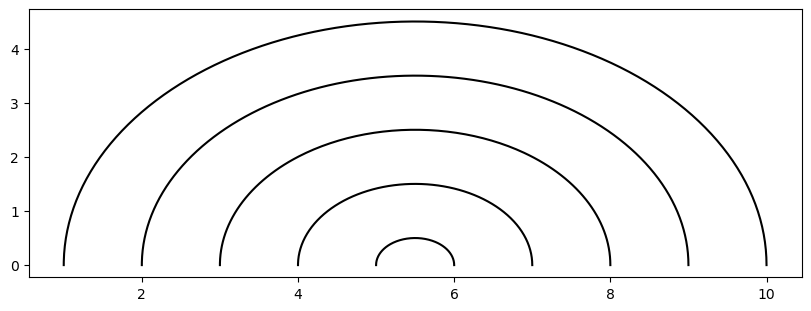

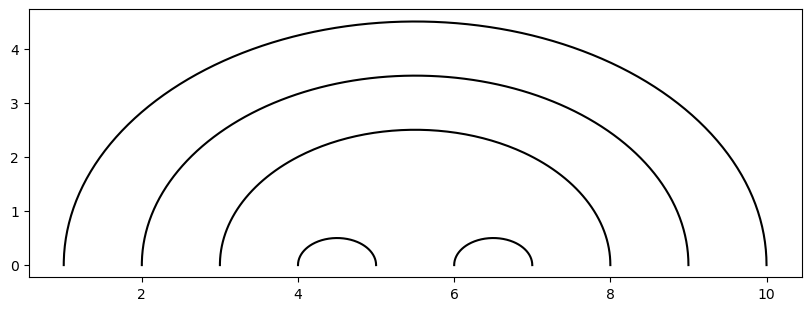

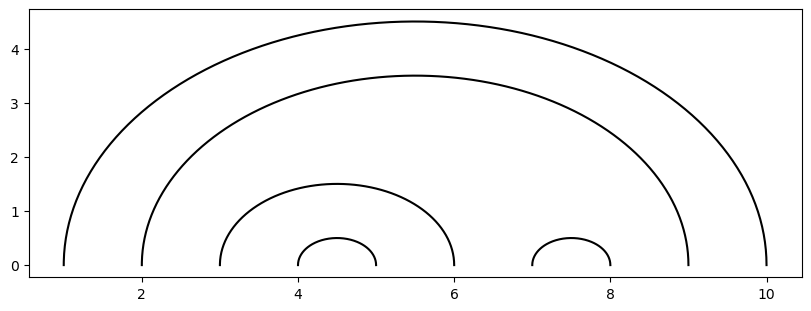

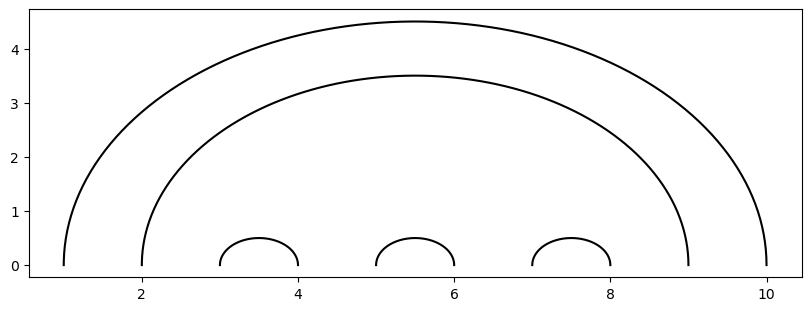

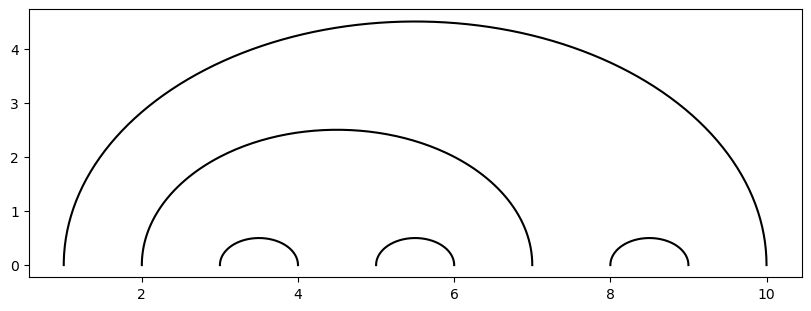

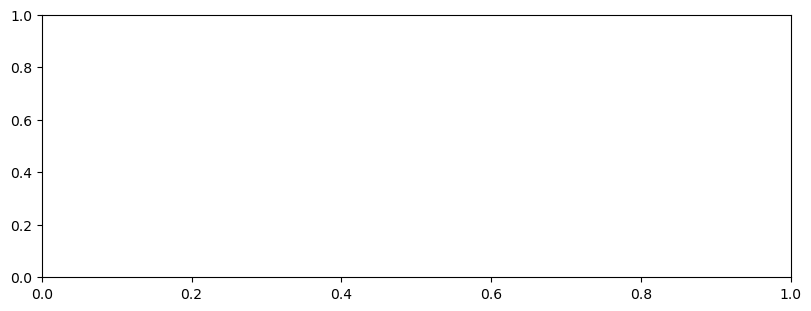

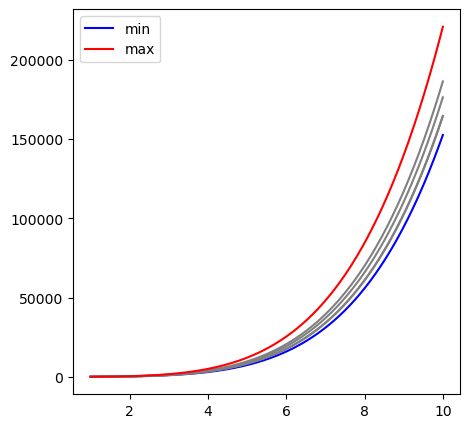

0.0 + 10.0·x + 16.0·x² + 11.0·x³ + 4.0·x⁴ + 1.0·x⁵
0.0 + 6.0·x + 17.0·x² + 13.0·x³ + 5.0·x⁴ + 1.0·x⁵
0.0 + 8.0·x + 15.0·x² + 13.0·x³ + 5.0·x⁴ + 1.0·x⁵
0.0 + 4.0·x + 15.0·x² + 15.0·x³ + 7.0·x⁴ + 1.0·x⁵
0.0 + 6.0·x + 14.0·x² + 15.0·x³ + 6.0·x⁴ + 1.0·x⁵
0.0 + 1.0·x + 10.0·x² + 20.0·x³ + 10.0·x⁴ + 1.0·x⁵


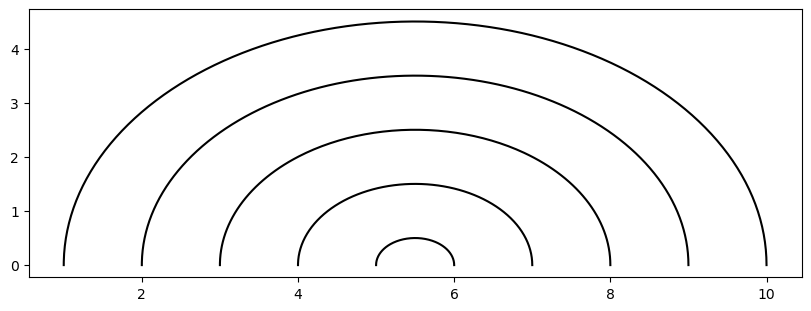

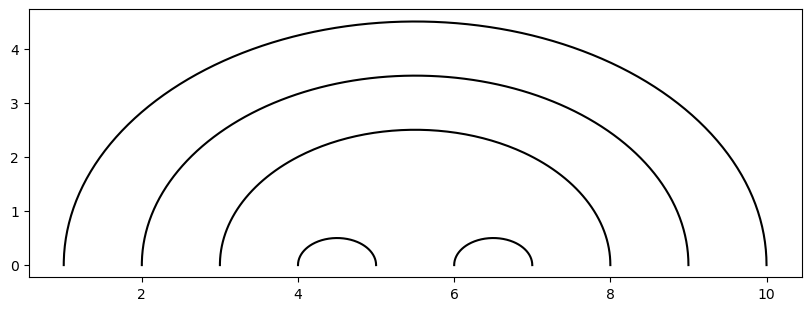

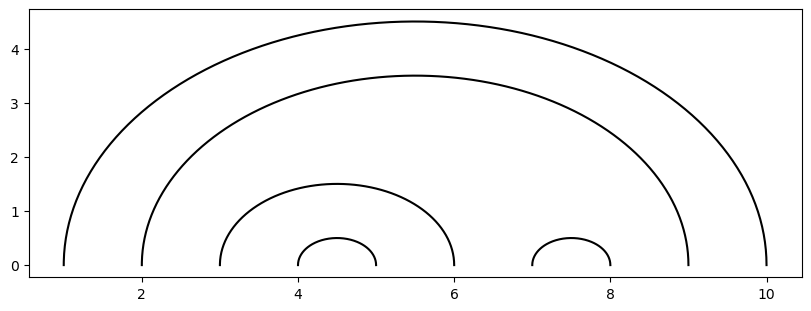

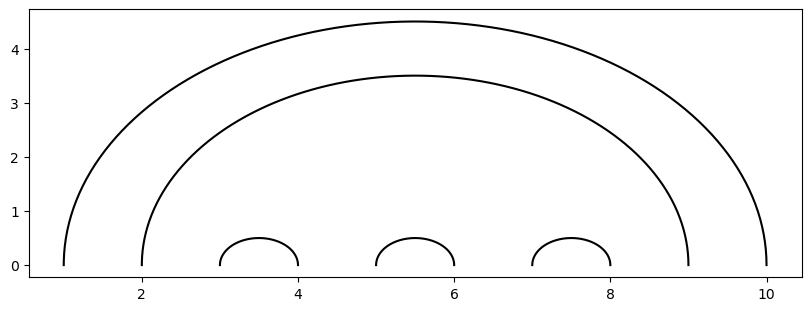

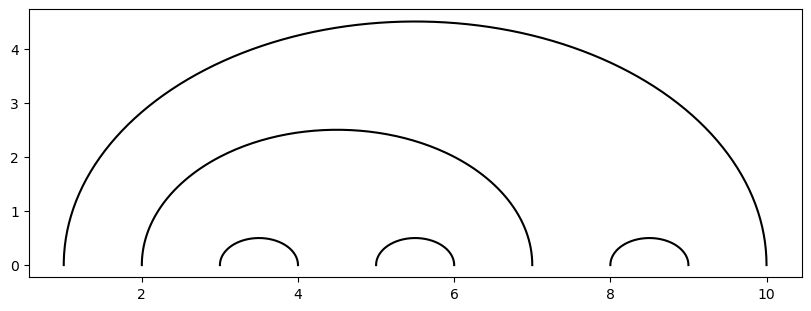

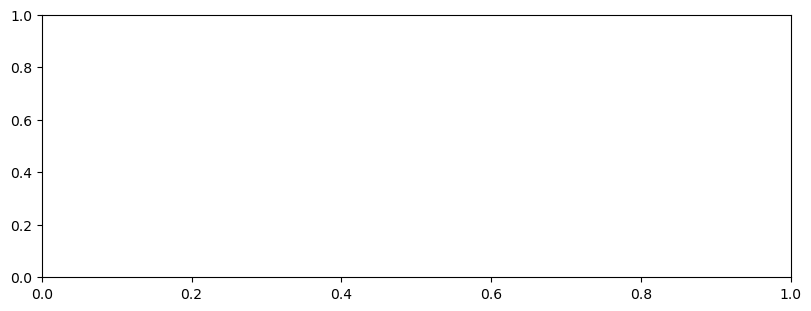

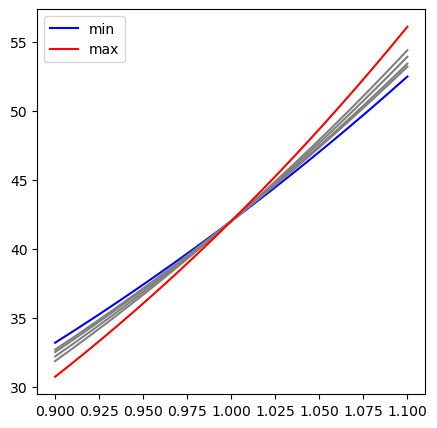

'\ncorrelations = []\nfor i in range(6):\n    M, arches, heights = meander_matrix(i+3, "lex")\n    corr, sums, minima, maxima, indices = matrix_data(M, heights, should_print = false)\n    orbits = arch_orbits(arches)\n    reps = get_reps(arches, orbits)\n    num_components = [sums[r] for r in reps]\n    heights = [heights[r] for r in reps]\n    data = np.column_stack([heights, num_components])\n    print(data)\n    corr = np.corrcoef(data, rowvar=False)\n    correlations.append(corr[1,0])\n    print(i)\nprint(correlations)\n'

In [45]:
Sym = SymmetricFunctions(QQ)
s = Sym.s()
p = Sym.p()
R = PolynomialRing(QQ, 't')
t = R.gen();
mu = (t)

x=DyckWord("(((())))")
y=DyckWord("()()()()")
m=Meander(x,y)
draw_arch_diagram(x)
draw_arch_diagram(y)
draw_meander(m)
x=DyckWord("((((((((((((((((((((()))))))))))))))))))))")
y=DyckWord("((((((((((((()))))))))))))(((((((())))))))")
m=Meander(x,y)
draw_meander(m)


# Meander matrix and it's data
M, arches, heights = meander_matrix(6, "lex")
corr, rep_corr, sums, minima, maxima, indices = matrix_data(M, heights)

# Meandric orbits matrix and some data
labels, num_orbits, orbits = orbit_label_matrix(M, arches)
print("Number of orbits: ", num_orbits)

size_counts = Counter(len(o) for o in orbits)

for size in sorted(size_counts):
    print(f"Size {size}: {size_counts[size]} sets")

plt.imshow(labels, cmap='tab20')
plt.colorbar()
plt.show()

    
"""find out sequence of orbit decomposition numbers"""
for i in range(1,6):
    M, arches, heights = meander_matrix(i, "lex")
    labels, num_orbits, orbits = orbit_label_matrix(M, arches)
    print("Orbit Analysis of n = ", i, ".")
    print("Number of orbits: ", num_orbits)
    size_counts = Counter(len(o) for o in orbits)
    for size in sorted(size_counts):
        print(f"Size {size}: {size_counts[size]} sets")
    reps = []

"""for i in indices:
    draw_arch_diagram(arches[i])
    print(sums[i])"""


# print("regular det: ", detNxN(M))
# dM = meander_determinant(M, 5)
# print("dF det: ", dM)
# print("The factorization of meander determinant: ", dM.factor())
# print("bareiss det: ", bareissDet(M))
# print("regular det: ", detNxN(M))
t0 = time.time()
H = matrix(stanley_matrix(3))
print("H matrix time elapsed:", time.time() - t0, "seconds")

t0 = time.time()
dH = H.determinant()
print("H det time elapsed:", time.time() - t0, "seconds")

t0 = time.time()
# f = dH.factor()
print("H factor time elapsed:", time.time() - t0, "seconds")

"""
sumTerms = 0
for i in range(len(H)):
    for j in range(len(H)):
        sumTerms += H[i][j]
print("is sum schur positive: ", sumTerms.is_schur_positive())
print("trace of M squared: ", trace_M_squared(M))
trHH = trace_M_squared(H)
print("trace of H squared: ", trHH)
print("is trace of H^2 schur positive: ", trHH.is_schur_positive())
"""


# print(dH.realization_of().shur())
# matrixPrint(H)

# test = p[1, 1, 1, 1, 1, 1] - 6*p[2, 2, 1, 1] + 3*p[3, 1, 1, 1] + 2*p[3, 3]
test = (p[1, 1, 1] - p[3])^3

"""
t0 = time.time()
print(schur_positive(f))
print("Schur positivity check time elapsed:", time.time() - t0, "seconds")
"""

"""
for i in range(1,10):
    n = i*4
    ret = 0
    for k in range(i+1):
        ret += comb(2*i, 2*k)*catalan_number(k)*catalan_number(i-k)
    print(ret)
"""


for i in range(6):
    M, arches, heights = meander_matrix(i+1, "norm")
    sums = M.sum(axis=1)
    # matrix_print(M)
    count = np.count_nonzero(M==i/2)
    # print(count)
    print("min: ", sums.min())
    print("max: ", sums.max())
    # print("total: ", sums.sum())

arch_polynomial_graphs(5, 1, 10)
arch_polynomial_graphs(5, 0.9, 1.1)

"""
M, arches, heights = meander_matrix(5, "norm")
corr, sums, minima, maxima, indices = matrix_data(M, heights)
orbits = arch_orbits(arches)
reps = get_reps(arches, orbits)
num_components = [sums[r] for r in reps]
heights = [heights[r] for r in reps]
data = np.column_stack([heights, num_components])
corr = np.corrcoef(data, rowvar=False)
print(corr)
"""

"""
ud_n = DyckWord("()" * n)
for i in range(10):
    print(maximal_component_sum(i, ud_n))
"""

"""
correlations = []
for i in range(6):
    M, arches, heights = meander_matrix(i+3, "lex")
    corr, sums, minima, maxima, indices = matrix_data(M, heights, should_print = false)
    orbits = arch_orbits(arches)
    reps = get_reps(arches, orbits)
    num_components = [sums[r] for r in reps]
    heights = [heights[r] for r in reps]
    data = np.column_stack([heights, num_components])
    print(data)
    corr = np.corrcoef(data, rowvar=False)
    correlations.append(corr[1,0])
    print(i)
print(correlations)
"""


